# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_:
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Maribao, Jake Agustin
- _Student No._: 2023-08777
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![figure](Given_Function.png)

**Figure 1.** $f(x)$ on $[-2, 5]$ with the $y$-axis cropped to $[-50, 50]$. The function
crosses zero twice, near $x \approx -1.19$ and $x \approx 4.60$, and stays at or below zero
in between, dipping to about $-8$ near $x = -0.7$ and $-46$ near $x = 4.1$. At this scale
the stretch around $x = 2$ looks flat against the axis.

![figure](Given_Function_(scaled_down).png)

**Figure 2.** The same function with the $y$-axis cropped to $[-0.5, 0.5]$. The zoom shows
$f$ rising to touch zero at $x = 2$ and turning back down without crossing, the signature
of a double root. The two genuine crossings appear as near-vertical lines because the slope
is steep there ($|f'| \approx 40$ at $-1.19$ and $240$ at $4.60$).

![figure](convergence.png)

**Figure 3 (report figure).** Iterates $x_i$ against iteration $i$ for eleven runs of the
four root finders, labelled by method and starting values, with the three roots
($-1.1927$, $2$, $4.5959$) as dashed lines. All runs converge; iteration counts range from
6 (Newton on a simple root) to 50 (fixed point with $x = \ln(x^3 + 2)$). The secant run
from $x_0, x_1 = 1, 1.5$ overshoots to $x \approx 8$ at $i = 8$ before returning, and the
longest tails belong to the runs converging on the double root.

### Report discussion

**Explain the report figure.**

Every curve flattens onto a dashed root line, so all eleven runs converge, at
different rates. Newton and secant aimed at the simple roots settle within 6 to
13 iterations (quadratic or superlinear error decay). Bisection needs 31 to
33 because each step only halves the bracket, one binary digit per iteration. Fixed-point maps converge linearly at a rate set by
$|g'|$ at the root: 11 steps for the cube-root map ($|g'| \approx 0.07$), 50 for the
logarithm map ($|g'| \approx 0.64$). The long tails toward $x = 2$ are the double root:
$f'$ vanishes with $f$, so Newton drops to linear convergence with error ratio $\tfrac12$
(31 steps) and secant to 47. Bisection cannot bracket this root (the $[1, 3]$ attempt
fails); the $[-1, 2]$ run reaches it only because $f(2)$ evaluates to exactly $0$, so the
endpoint itself is the answer and $a$ walks up to it.

**What are the advantages and disadvantages of the root-finding methods?**

*Bisection* always converges once a sign-changing bracket exists and needs no derivative,
but it is slow (one bit per step), needs a bracket, and cannot find roots of even
multiplicity. *Fixed point* is the simplest to code and needs no derivative, but it
converges only if the rearrangement has $|g'| < 1$ near the root, the rate is linear, and
a contracting $g$ is problem specific. *Newton* is the fastest (quadratic) and needs one
starting value, but it requires $f'$, costs two evaluations per step (the table shows
$2N$), is only locally convergent (a poor guess can diverge or land on a different root),
and degrades to linear at a multiple root. *Secant* keeps near-Newton speed at one
evaluation per step and no derivative, but it needs two starting values, has no
convergence guarantee, and fails if $f(x_i) = f(x_{i-1})$. In practice: bracket with
bisection, then polish with Newton.

### Other comments
- The problem statement's "$x = -2$ to $x = -5$" was read as $[-2, 5]$; that interval
  contains all three roots and matches the request to crop the $y$-axis.
- A secant run started at $x_0 = -2$, $x_1 = 0$ wandered to the double root instead of the
  nearby root at $-1.19$, a reminder that the secant method is not a bracketing method even
  when its starting values straddle a root; $x_0 = -1.5$, $x_1 = -1$ is used instead.
- The `bisection [-1, 2]` row is a degenerate case, not a counterexample to the notes: the
  bracket test $f(a)f(b) > 0$ is passed only because $f(2.0)$ rounds to $0$, and the method
  never moves $b$ off the root it was handed.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

**Problem 1 notes**

*Structure of $f$.* Grouping terms, $f(x) = (x-2)^2\,(e^x - x^3 - 2)$. So $x = 2$ is a
double root, where $f$ touches zero without changing sign, and the other roots solve
$e^x = x^3 + 2$: one near $-1.19$ and one near $4.60$. The problem's "from $x=-2$ to
$x=-5$" is read as $[-2, 5]$, which contains all three.

*Methods.* The finders follow Gezerlis Codes 5.1 to 5.3 : $f$ values are cached so each step costs one evaluation, the
stopping test is the textbook's relative one, $|x_{i+1} - x_i| < \mathrm{tol}\cdot\max(1, |x_{i+1}|)$,
and running out of iterations raises an error instead of returning silently. Two changes
from the textbook: every finder returns the full list of iterates so convergence can be
plotted (the last entry is the estimate), and bisection checks that its starting bracket
actually changes sign. A wrapper counts evaluations so the per-step cost of each method is
verified in the results table rather than asserted.
1. *Fixed point*: rearrange $e^x = x^3 + 2$ as $x = g(x)$ and iterate. This converges only
   where $|g'| < 1$, so two rearrangements are used: $x = \sqrt[3]{e^x - 2}$ for the root
   near $-1.19$ and $x = \ln(x^3 + 2)$ for the root near $4.60$.
2. *Bisection*: halve a bracket $[a, b]$ with $f(a)f(b) < 0$, keeping the half that still
   changes sign; the iterate is the midpoint. It cannot be applied to $x = 2$.
3. *Newton*: $x_{i+1} = x_i - f(x_i)/f'(x_i)$ with the analytic $f'$.
4. *Secant*: Newton with $f'$ replaced by the slope through the last two iterates, so it
   needs two starting values but no derivative.

In [2]:
def f(x):
    """f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 - 4x e^x + 8x + 4e^x - 8."""
    return (-x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2
            - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8)


def f_prime(x):
    """Analytic derivative of f, used by Newton's method."""
    return -5*x**4 + 16*x**3 - 12*x**2 - 4*x + 8 + np.exp(x)*(x**2 - 2*x)


# The four finders follow Gezerlis, Codes 5.1 to 5.3: f values are cached so each step costs one evaluation, the stopping test is relative, and running out of
# iterations is reported (for/else). Unlike the textbook they return every iterate [x_0, x_1, ...] so convergence can be plotted; the last entry is the root estimate.

def converged(x_new, x_old, tol):
    """Textbook test |dx / x| < tol, with max(1, |x|) so a root at x = 0 cannot divide by zero."""
    return abs(x_new - x_old) < tol*max(1.0, abs(x_new))


def fixed_point(g, x0, tol=1e-10, max_iter=100):
    """Relaxation. Iterates x_{i+1} = g(x_i) for a rearrangement f(x) = 0 <=> x = g(x)."""
    history = [x0]
    for _ in range(max_iter):
        history.append(g(history[-1]))
        if converged(history[-1], history[-2], tol):
            break
    else:
        raise RuntimeError(f"fixed_point did not converge in {max_iter} iterations")
    return history

def bisection(f, a, b, tol=1e-10, max_iter=100):
    """Bracketing. Halves [a, b] while keeping a sign change; iterates are the midpoints."""
    fa, fb = f(a), f(b)
    if fa*fb > 0:
        raise ValueError(f"f({a}) and f({b}) have the same sign, no bracket")
    history = [0.5*(a + b)]
    for _ in range(max_iter):
        m = history[-1]
        fm = f(m)
        if fm == 0:
            break
        if fa*fm < 0:
            b = m
        else:
            a, fa = m, fm
        history.append(0.5*(a + b))
        if converged(history[-1], m, tol):
            break
    else:
        raise RuntimeError(f"bisection did not converge in {max_iter} iterations")
    return history


def newton(f, f_prime, x0, tol=1e-10, max_iter=100):
    """Known derivative. x_{i+1} = x_i - f(x_i) / f'(x_i); one f and one f' per step."""
    history = [x0]
    for _ in range(max_iter):
        x = history[-1]
        history.append(x - f(x)/f_prime(x))
        if converged(history[-1], x, tol):
            break
    else:
        raise RuntimeError(f"newton did not converge in {max_iter} iterations")
    return history


def secant(f, x0, x1, tol=1e-10, max_iter=100):
    """Approximate derivative. Newton with f' replaced by the slope through the last two
    iterates; f values are carried over so each step costs one evaluation."""
    history = [x0, x1]
    f0, f1 = f(x0), f(x1)
    for _ in range(max_iter):
        if f1 == f0:
            raise RuntimeError("secant is flat: f(x_i) == f(x_{i-1})")
        x2 = x1 - f1*(x1 - x0)/(f1 - f0)
        history.append(x2)
        if converged(x2, x1, tol):
            break
        x0, x1, f0, f1 = x1, x2, f1, f(x2)
    else:
        raise RuntimeError(f"secant did not converge in {max_iter} iterations")
    return history

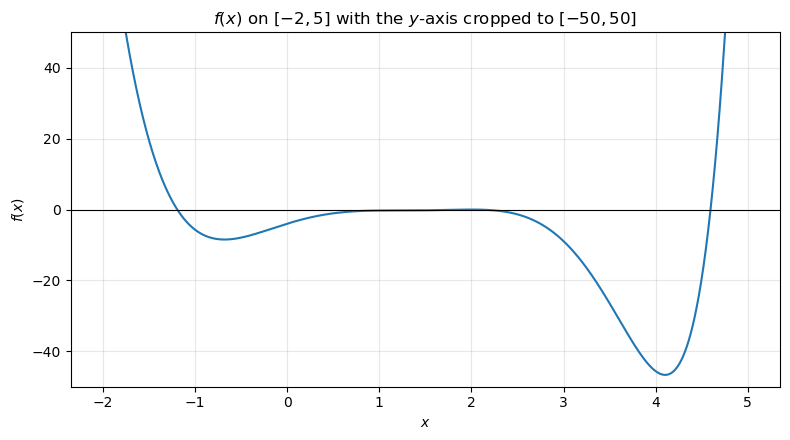

In [3]:
# Plot of the given function f(x) below.

x = np.linspace(-2, 5, 1401)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, f(x), lw=1.5)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylim(-50, 50)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('$f(x)$ on $[-2, 5]$ with the $y$-axis cropped to $[-50, 50]$')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig('Given_Function')

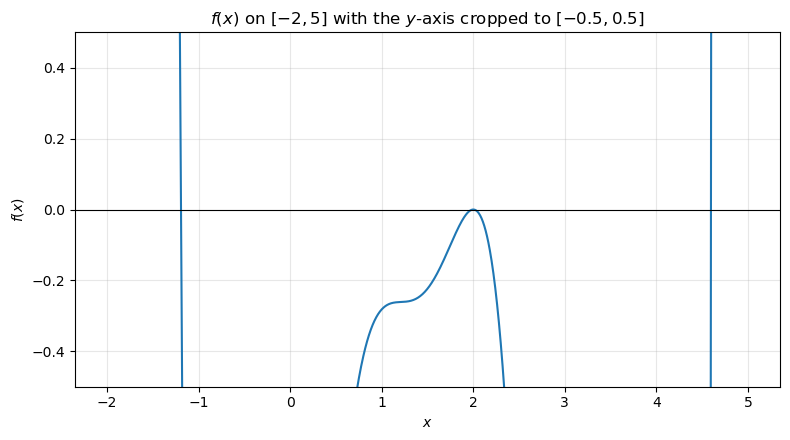

In [4]:
# Scaled down to see the zeroes closer.

x = np.linspace(-2, 5, 1401)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, f(x), lw=1.5)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('$f(x)$ on $[-2, 5]$ with the $y$-axis cropped to $[-0.5, 0.5]$')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig('Given_Function_(scaled_down)')

In [5]:
#Implementation
# Rearrangements f(x) = 0 <=> x = g(x) for the fixed-point method. With
# f = (x - 2)^2 (e^x - x^3 - 2), the simple roots satisfy e^x = x^3 + 2.
g_cbrt = lambda x: np.cbrt(np.exp(x) - 2)     # |g'| < 1 near x = -1.19
g_log = lambda x: np.log(x**3 + 2)            # |g'| < 1 near x =  4.60


def counted(func):
    """Wrap func so that wrapper.calls records how many times it was evaluated."""
    def wrapper(x):
        wrapper.calls += 1
        return func(x)
    wrapper.calls = 0
    return wrapper


runs, evals = {}, {}


def record(name, method, func, *args, deriv=None):
    """Run one finder, store its iterates in runs and its f (+ f') evaluation count in evals."""
    fc = counted(func)
    extra = (counted(deriv),) if deriv is not None else ()
    runs[name] = method(fc, *extra, *args)
    evals[name] = fc.calls + sum(w.calls for w in extra)


record('bisection [-2, 0]',                bisection, f, -2.0, 0.0)
record('bisection [4, 5]',                 bisection, f, 4.0, 5.0)
record('bisection [-1, 2]',                 bisection, f, -1.0, 2.0)
record('newton x0 = -1',                   newton, f, -1.0, deriv=f_prime)
record('newton x0 = 1.5',                  newton, f, 1.5, deriv=f_prime)
record('newton x0 = 5',                    newton, f, 5.0, deriv=f_prime)
record('secant x0, x1 = -1.5, -1',         secant, f, -1.5, -1.0)
record('secant x0, x1 = 1, 1.5',           secant, f, 1.0, 1.5)
record('secant x0, x1 = 4, 5',             secant, f, 4.0, 5.0)
record('fixed point x = cbrt(e^x - 2), x0 = 0', fixed_point, g_cbrt, 0.0)
record('fixed point x = ln(x^3 + 2), x0 = 3',   fixed_point, g_log, 3.0)

print(f"{'run':40s} {'root':>14s} {'iterations':>11s} {'f, f` evals':>12s} {'|f(root)|':>10s}")
for name, hist in runs.items():
    print(f"{name:40s} {hist[-1]:14.10f} {len(hist) - 1:11d} {evals[name]:12d} {abs(f(hist[-1])):10.1e}")

# The double root at x = 2 cannot be bracketed, since f <= 0 on both sides of it.
try:
    bisection(f, 1.0, 3.0)
except ValueError as err:
    print("\nbisection on [1, 3]:", err)

run                                                root  iterations  f, f` evals  |f(root)|
bisection [-2, 0]                         -1.1926857651          33           35    3.0e-09
bisection [4, 5]                           4.5958635651          31           33    4.4e-08
bisection [-1, 2]                          1.9999999721          28           31    0.0e+00
newton x0 = -1                            -1.1926857650           6           12    3.6e-15
newton x0 = 1.5                            2.0000000511          31           62    0.0e+00
newton x0 = 5                              4.5958635649           6           12    5.1e-13
secant x0, x1 = -1.5, -1                  -1.1926857650           9            9    3.6e-15
secant x0, x1 = 1, 1.5                     1.9999999655          47           47    0.0e+00
secant x0, x1 = 4, 5                       4.5958635649          13           13    4.5e-13
fixed point x = cbrt(e^x - 2), x0 = 0     -1.1926857650          11           11

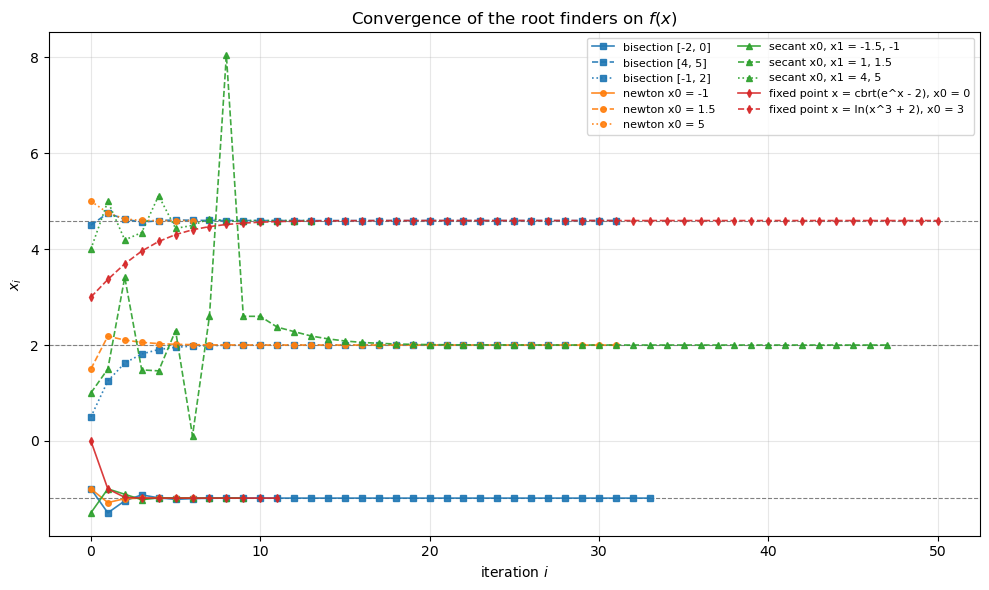

In [6]:
#Conergence of the values toward the roots of f(x).

roots = sorted({round(h[-1], 6) for h in runs.values()})
colour = {'bisection': 'C0', 'newton': 'C1', 'secant': 'C2', 'fixed': 'C3'}
marker = {'bisection': 's', 'newton': 'o', 'secant': '^', 'fixed': 'd'}
linestyles = ['-', '--', ':']

fig, ax = plt.subplots(figsize=(10, 6))
for r in roots:
    ax.axhline(r, color='gray', lw=0.8, ls='--')
seen = {}
for name, hist in runs.items():
    method = name.split()[0]
    k = seen.get(method, 0)
    seen[method] = k + 1
    ax.plot(range(len(hist)), hist, marker=marker[method], ms=4, lw=1.2,
            color=colour[method], ls=linestyles[k], alpha=0.9, label=name)
ax.set_xlabel('iteration $i$')
ax.set_ylabel('$x_i$')
ax.set_title('Convergence of the root finders on $f(x)$')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig('convergence')

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

**Problem 1 code summary**

Four root finders are written as small, independent functions that share one convention:
each returns the complete list of iterates rather than only the final value, so a single
dictionary of runs feeds both the results table and the convergence figure without
recomputing anything. The function is first factorised to locate the roots and to spot the
double root at $x = 2$, which decides where each method can be applied and which
rearrangements make the fixed-point iteration contract. The finders adapt the textbook
listings (cached $f$ values, relative tolerance, for/else failure flag) and a small counter
verifies their per-step cost; analytic $f'$ is supplied to Newton so its quadratic
convergence is not spoiled by a finite-difference derivative.